In [1]:
# Individual Task 1 - Part 1.3 Data Analysis
# Two ML models: Decision Tree (Dataset A) and kNN Regressor (Dataset B)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# Load Dataset A - Healthcare Dataset
# -----------------------------
data1 = pd.read_csv('healthcare_dataset.csv')
print("Dataset A shape:", data1.shape)
data1.head()

Dataset A shape: (55500, 15)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [4]:
# I'm going to use some patient info to try predict the Test Results column
# Test Results has 3 categories: Normal, Abnormal, Inconclusive
cols_needed = ['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Admission Type',
               'Insurance Provider', 'Billing Amount']

In [5]:
X1 = data1[cols_needed].copy()
y1 = data1['Test Results'].copy()

# most of these columns are text so I need to convert them to numbers
# using LabelEncoder for each categorical column
encoder = LabelEncoder()
X1['Gender'] = encoder.fit_transform(X1['Gender'])
X1['Blood Type'] = encoder.fit_transform(X1['Blood Type'])
X1['Medical Condition'] = encoder.fit_transform(X1['Medical Condition'])
X1['Admission Type'] = encoder.fit_transform(X1['Admission Type'])
X1['Insurance Provider'] = encoder.fit_transform(X1['Insurance Provider'])

# also need to encode the target column
y_encoder = LabelEncoder()
y1_encoded = y_encoder.fit_transform(y1)


In [6]:
# split into training and test sets (80/20)
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1_encoded, test_size=0.2, random_state=42
)

In [7]:
# train a decision tree classifier
tree_model = DecisionTreeClassifier(max_depth=6, random_state=42)
tree_model.fit(X1_train, y1_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [8]:
# make predictions on test set
y1_pred = tree_model.predict(X1_test)


In [10]:
# check how well it did
print("\n--- Decision Tree Results (Dataset A) ---")
print("Accuracy:", accuracy_score(y1_test, y1_pred))
print("Precision (macro avg):", precision_score(y1_test, y1_pred, average='macro'))
print("Recall (macro avg):", recall_score(y1_test, y1_pred, average='macro'))
print("F1 Score (macro avg):", f1_score(y1_test, y1_pred, average='macro'))


--- Decision Tree Results (Dataset A) ---
Accuracy: 0.33837837837837836
Precision (macro avg): 0.3364358372362454
Recall (macro avg): 0.33680035662265095
F1 Score (macro avg): 0.32956124228982225


In [11]:
# Load Dataset B - Hospital Bed Occupancy
# -----------------------------
data2 = pd.read_csv('bed.csv')  # change filename if needed
print("\nDataset B shape:", data2.shape)
data2.head()


Dataset B shape: (90, 8)


,Date,Occupancy,Day_of_Week,Month,Year,Holiday,Prev_Occupancy,Prev_2_Occupancy
0,2022-01-01,120,5,1,2022,1,115,110
1,2022-01-02,130,6,1,2022,1,120,115
2,2022-01-03,125,0,1,2022,0,130,120
3,2022-01-04,140,1,1,2022,0,125,130
4,2022-01-05,145,2,1,2022,0,140,125


In [12]:
# this dataset already has "lag" columns (previous day/2 days occupancy)
# going to use those plus calendar info to predict Occupancy
feature_cols = ['Day_of_Week', 'Month', 'Year', 'Holiday', 'Prev_Occupancy', 'Prev_2_Occupancy']


In [13]:
X2 = data2[feature_cols].copy()
y2 = data2['Occupancy'].copy()

# encode Day_of_Week and Holiday if they are text, not numbers
if X2['Day_of_Week'].dtype == 'object':
    X2['Day_of_Week'] = encoder.fit_transform(X2['Day_of_Week'])
if X2['Holiday'].dtype == 'object':
    X2['Holiday'] = encoder.fit_transform(X2['Holiday'])

# split into train/test again
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

In [14]:
# train kNN regressor with k = 5
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X2_train, y2_train)

KNeighborsRegressor()

In [15]:
y2_pred = knn_model.predict(X2_test)

In [16]:
# check results using regression metrics
print("\n--- kNN Regressor Results (Dataset B) ---")
print("MAE:", mean_absolute_error(y2_test, y2_pred))
print("RMSE:", np.sqrt(mean_squared_error(y2_test, y2_pred)))
print("R2 Score:", r2_score(y2_test, y2_pred))


--- kNN Regressor Results (Dataset B) ---
MAE: 4.944444444444445
RMSE: 6.372684764768387
R2 Score: 0.999244827126076


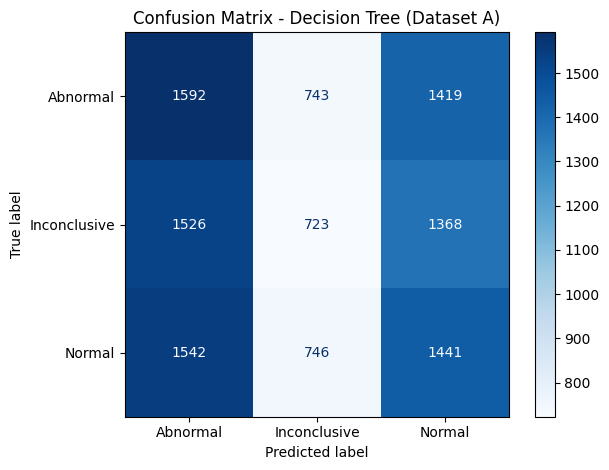

In [17]:
# Making a confusion matrix to see where the Decision Tree got things wrong
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# comparing the actual test labels to what the model predicted
cm = confusion_matrix(y1_test, y1_pred)

# getting the original label names back (Normal, Abnormal, Inconclusive)
# instead of just numbers
class_names = y_encoder.classes_

# plotting it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Decision Tree (Dataset A)")
plt.tight_layout()
plt.savefig('confusion_matrix_dataset_A.png', dpi=150)  # saving so I can use it later
plt.show()

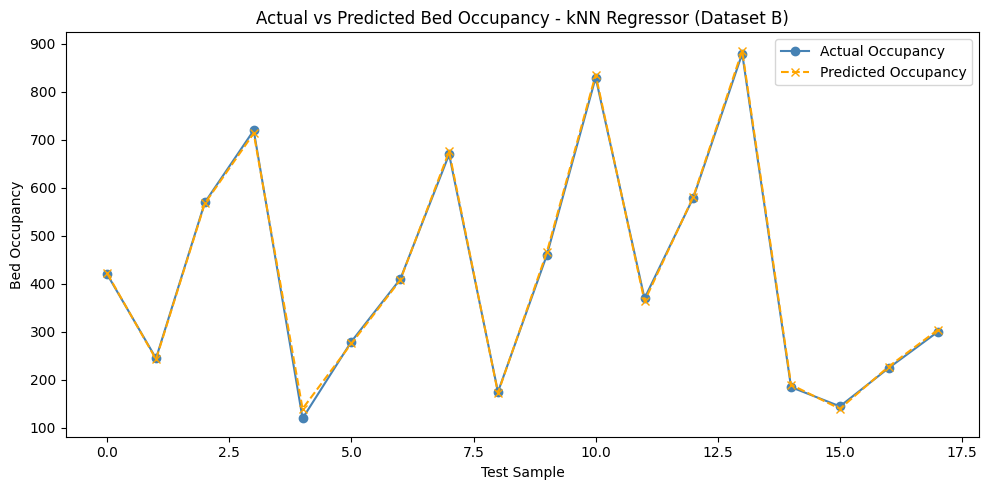

In [18]:
# Now plotting actual vs predicted bed occupancy for the kNN model
# just want to see visually how close the predictions were
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# plotting the real values first
plt.plot(range(len(y2_test)), y2_test.values, marker='o', label='Actual Occupancy', color='steelblue')

# then plotting what the model predicted, using a dashed line so it's easy to tell apart
plt.plot(range(len(y2_pred)), y2_pred, marker='x', label='Predicted Occupancy', color='orange', linestyle='--')

plt.xlabel("Test Sample")
plt.ylabel("Bed Occupancy")
plt.title("Actual vs Predicted Bed Occupancy - kNN Regressor (Dataset B)")
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted_occupancy.png', dpi=150)
plt.show()

In [19]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold

# Dataset A - Decision Tree - using StratifiedKFold since it's classification
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_a = cross_val_score(tree_model, X1, y1_encoded, cv=skf, scoring='accuracy')

print("--- Dataset A: 5-Fold Cross-Validation (Decision Tree) ---")
print("Fold accuracies:", cv_scores_a)
print("Mean accuracy:", cv_scores_a.mean())
print("Std dev:", cv_scores_a.std())

# Dataset B - kNN Regressor - using plain KFold since it's regression
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_b = cross_val_score(knn_model, X2, y2, cv=kf, scoring='r2')

print("\n--- Dataset B: 5-Fold Cross-Validation (kNN Regressor) ---")
print("Fold R2 scores:", cv_scores_b)
print("Mean R2:", cv_scores_b.mean())
print("Std dev:", cv_scores_b.std())

--- Dataset A: 5-Fold Cross-Validation (Decision Tree) ---
Fold accuracies: [0.3390991  0.33882883 0.33603604 0.32594595 0.33594595]
Mean accuracy: 0.3351711711711712
Std dev: 0.004801252440558701

--- Dataset B: 5-Fold Cross-Validation (kNN Regressor) ---
Fold R2 scores: [0.99924483 0.99820446 0.99913415 0.99461177 0.99916699]
Mean R2: 0.9980724406164597
Std dev: 0.0017716331814644649


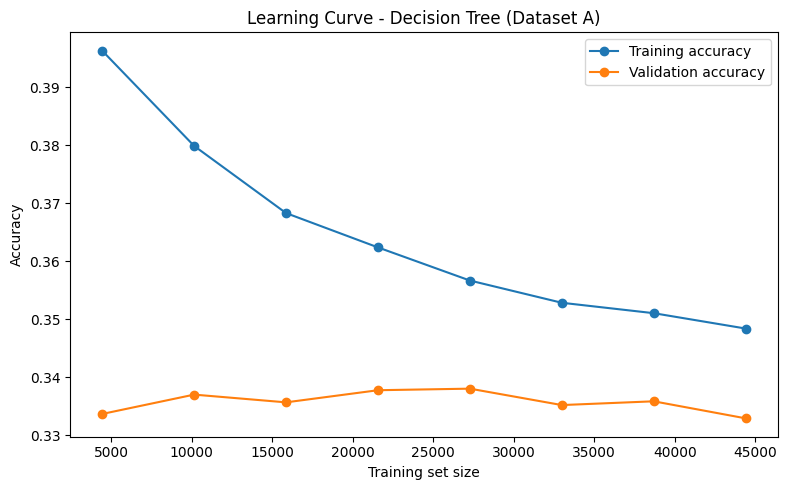

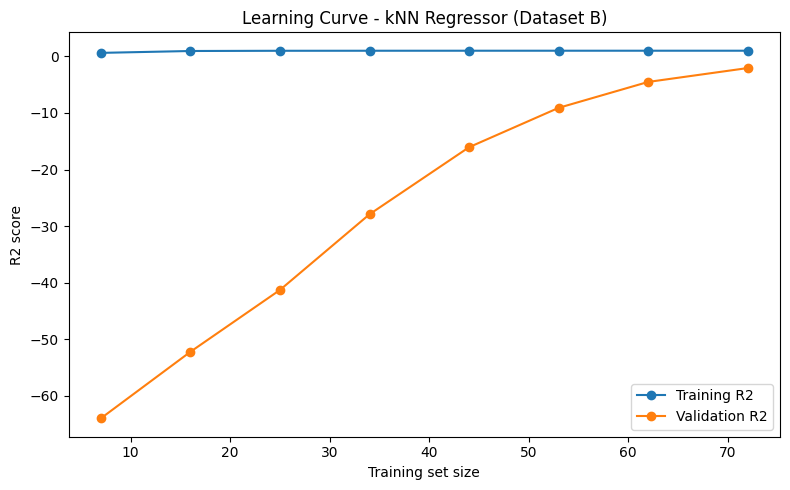

In [20]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# --- Dataset A: Decision Tree learning curve ---
train_sizes_a, train_scores_a, test_scores_a = learning_curve(
    DecisionTreeClassifier(max_depth=6, random_state=42),
    X1, y1_encoded,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8),
    random_state=42
)

train_mean_a = train_scores_a.mean(axis=1)
test_mean_a = test_scores_a.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_a, train_mean_a, marker='o', label='Training accuracy')
plt.plot(train_sizes_a, test_mean_a, marker='o', label='Validation accuracy')
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Decision Tree (Dataset A)")
plt.legend()
plt.tight_layout()
plt.savefig('learning_curve_dataset_A.png', dpi=150)
plt.show()

# --- Dataset B: kNN learning curve ---
train_sizes_b, train_scores_b, test_scores_b = learning_curve(
    KNeighborsRegressor(n_neighbors=5),
    X2, y2,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    random_state=42
)

train_mean_b = train_scores_b.mean(axis=1)
test_mean_b = test_scores_b.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_b, train_mean_b, marker='o', label='Training R2')
plt.plot(train_sizes_b, test_mean_b, marker='o', label='Validation R2')
plt.xlabel("Training set size")
plt.ylabel("R2 score")
plt.title("Learning Curve - kNN Regressor (Dataset B)")
plt.legend()
plt.tight_layout()
plt.savefig('learning_curve_dataset_B.png', dpi=150)
plt.show()

In [22]:
test_results_df = X1_test.copy()
test_results_df['true_label'] = y1_test
test_results_df['pred_label'] = y1_pred
test_results_df['correct'] = (test_results_df['true_label'] == test_results_df['pred_label'])

print("--- Fairness Check: Decision Tree Accuracy by Gender (Dataset A) ---")
gender_encoder = LabelEncoder()
gender_encoder.fit(data1['Gender'])
print("Gender encoding:", dict(zip(gender_encoder.classes_, gender_encoder.transform(gender_encoder.classes_))))

accuracy_by_gender = test_results_df.groupby('Gender')['correct'].mean()
count_by_gender = test_results_df.groupby('Gender')['correct'].count()

print("\nAccuracy by Gender group:")
print(accuracy_by_gender)
print("\nNumber of test samples per Gender group:")
print(count_by_gender)

fairness_gap = accuracy_by_gender.max() - accuracy_by_gender.min()
print(f"\nFairness gap (max - min accuracy across Gender groups): {fairness_gap:.4f}")

--- Fairness Check: Decision Tree Accuracy by Gender (Dataset A) ---
Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1)}

Accuracy by Gender group:
Gender
0    0.332077
1    0.344728
Name: correct, dtype: float64

Number of test samples per Gender group:
Gender
0    5571
1    5529
Name: correct, dtype: int64

Fairness gap (max - min accuracy across Gender groups): 0.0127
